<a href="https://colab.research.google.com/github/NicolaViolante/FruttaSRL/blob/master/ProgettoDefinitivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Traccia T4 - Riconoscimento animali da tracce audio

L' obbiettivo del seguente elaborato è quello di andare a costruire due differenti modelli che riescano a riconoscere diversi animali(nel caso particolare cani, gatti e delfini) a partire dalla registrazione del loro verso. Il primo modello prende in input direttamente la forme d'onda associata a ciascuna traccia considerabile come una sequenza, mentre il secondo modello prende in input lo spettrogramma di ciascuna traccia, che è la rappresentazione grafica dell'intensità del suono in funzione del tempo e della frequenza.

#Preparazione dei dati

Inizio con l'importare le diverse librerie e i diversi moduli che mi serviranno per svilppare il codice del mio progetto. In particolare uso:

*   Tensorflow: la libreria fondamentale per la costruzione dei miei modelli, per la gestione dei dati, il lavoro con tensori e l'ottimizzazione dei dati
*   Keras: modulo di tensorflow che semplifica creazione e addestramento delle reti neurali grazie a suoi strumenti messi a disposizione
*   Numpy: per lavorare e manipolare i tensori
*   Sklearn: usata per dividere il dataset in modo da costituire i diversi set, inoltre usata per analizzare le prestazioni ddel modello dopo la costruzione della matrice di confusione
*   Matplotlib: una libreria di visualizzazione dati che viene utilizzata per tracciare grafici
*   Librosa: usata per visualizzazione di dati audio, in particolare per tracciare gli spettrogrammi
*   Pandas: usata per tracciare i grafici di apprendimento e per organizzare i dati durante l'analisi


In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.layers import Input, Conv1D, Dense, Add, GlobalAveragePooling1D, Dropout, Conv2D, Flatten, GlobalAveragePooling2D, BatchNormalization, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
import tensorflow.keras.layers as layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import librosa.display
import pandas as pd

In questa parte di codice procedo a costruire i dataset che mi serviranno durante la fase d'addestramento e di test. In particolare utilizzo la funzione audio_dataset_from_directory(). Tramite questa specifico:

*   la directory nella quale sono presenti i dati
*   il dataset in formato straming
*   la lunghezza dell'audio in numero di campioni(se più corto della quantità indicata sarà paddato alla fine)
*   il modo in cui saranno codificate le etichette(one-hot)


In [ ]:
train_dir = "/content/drive/MyDrive/cats_dogs_dolphins/train"
test_dir = "/content/drive/MyDrive/cats_dogs_dolphins/test"

train_dataset = tf.keras.utils.audio_dataset_from_directory(
    directory=train_dir,
    batch_size=None,
    output_sequence_length=48000,
    label_mode="categorical",
)

test_dataset = tf.keras.utils.audio_dataset_from_directory(
    directory=test_dir,
    batch_size=None,
    output_sequence_length=48000,
    label_mode="categorical",
)

Found 325 files belonging to 3 classes.
Found 98 files belonging to 3 classes.


Qui faccio semplicemente un controllo sulle classi trovate

In [ ]:
class_names = train_dataset.class_names
print(f"Classi trovate: {class_names}")

Classi trovate: ['cat', 'dog', 'dolphin']


Ho scritto una funzione per convertire il dataset in tensori, facendo attenzione che i dati rimangano nello stesso ordine in modo da avere un associazione tra dato e label corrispondente

In [ ]:
def convert_to_tensor(dataset):
    audio_list = []
    label_list = []
    for audio, label in dataset:
        audio_list.append(audio.numpy())
        label_list.append(label.numpy())
    return tf.convert_to_tensor(audio_list), tf.convert_to_tensor(label_list)

Qui procedo ad utilizzare la funzione appena definita per convertire in tensori entrambi i dataset precedentemente costruiti che ho a disposizione

In [ ]:
train_audio, train_labels = convert_to_tensor(train_dataset)
test_audio, test_labels = convert_to_tensor(test_dataset)

Qui faccio semplicemente dei controlli sulla dimensionalità per verificare che tutto sia andato correttamente

In [ ]:
train_audio.shape

TensorShape([325, 48000, 1])

In [ ]:
train_labels.shape

TensorShape([325, 3])

In [ ]:
test_audio.shape

TensorShape([98, 48000, 1])

In [ ]:
test_labels.shape

TensorShape([98, 3])

Qui decido di ottenere validation set e test set sfruttando i dati provenienti dalla cartella test. Nonostante sappia che sarebbe meglio non toccare il test set, in quanto nella pratica non si ha controllo su di esso, a causa dei pochi dati a disposizione ho deciso di utilizzarli per avere una migliore distribuzione tra training, validation e test set.
In questo modo avrò:

*   **79.83%** dati nel training set
*   **11.58%** dati nel validation set
*   **11.58%** dati nel test set



In [ ]:
test_audio_np = test_audio.numpy()
test_labels_np = test_labels.numpy()

val_audio_np, test_audio_np, val_labels_np, test_labels_np = train_test_split(
    test_audio_np,
    test_labels_np,
    test_size=0.5,
    random_state=42,
    stratify=test_labels_np
)

val_audio = tf.convert_to_tensor(val_audio_np)
test_audio = tf.convert_to_tensor(test_audio_np)
val_labels = tf.convert_to_tensor(val_labels_np)
test_labels = tf.convert_to_tensor(test_labels_np)


A seguito della divisione, ho deciso di fare un ulteriore controllo per verificare che valori e labels associate siano state separate in modo corretto

In [ ]:
print(f"Train shape: {train_audio.shape}, Labels: {train_labels.shape}")
print(f"Validation shape: {val_audio.shape}, Labels: {val_labels.shape}")
print(f"Test shape: {test_audio.shape}, Labels: {test_labels.shape}")

unique, counts = np.unique(np.argmax(train_labels.numpy(), axis=1), return_counts=True)
print(f"Distribuzione delle classi nel training set: {dict(zip(class_names, counts))}")

unique, counts = np.unique(np.argmax(val_labels.numpy(), axis=1), return_counts=True)
print(f"Distribuzione delle classi nel validation set: {dict(zip(class_names, counts))}")

unique, counts = np.unique(np.argmax(test_labels.numpy(), axis=1), return_counts=True)
print(f"Distribuzione delle classi nel test set: {dict(zip(class_names, counts))}")


Train shape: (325, 48000, 1), Labels: (325, 3)
Validation shape: (49, 48000, 1), Labels: (49, 3)
Test shape: (49, 48000, 1), Labels: (49, 3)
Distribuzione delle classi nel training set: {'cat': 125, 'dog': 85, 'dolphin': 115}
Distribuzione delle classi nel validation set: {'cat': 20, 'dog': 14, 'dolphin': 15}
Distribuzione delle classi nel test set: {'cat': 19, 'dog': 14, 'dolphin': 16}


# Modello 1 - Analisi della forma d'onda

In questo primo modello prendo in input le forme d'onda. Queste possono essere viste come dati che hanno una struttura a griglia con topologia 1D. Per il training di questo modello è necessaria la GPU in quanto, in assenza di questa, la durata delle epoche di training avrebbe un costo a livello temporale insostenibile. Non avendo a disposizione una GPU nativa, e potendo solamente utilizzare quella messa a disposizione da Google Colab, non ho potuto testare velocemente e quando volevo molte configurazioni, per questo ho deciso di ridurre la lunghezza delle sequenze fornite in input alla rete rispetto al modello che utilizza lo spettrogramma. Nonostante ciò i risultati ottenuti sono stati più che soddisfacenti.

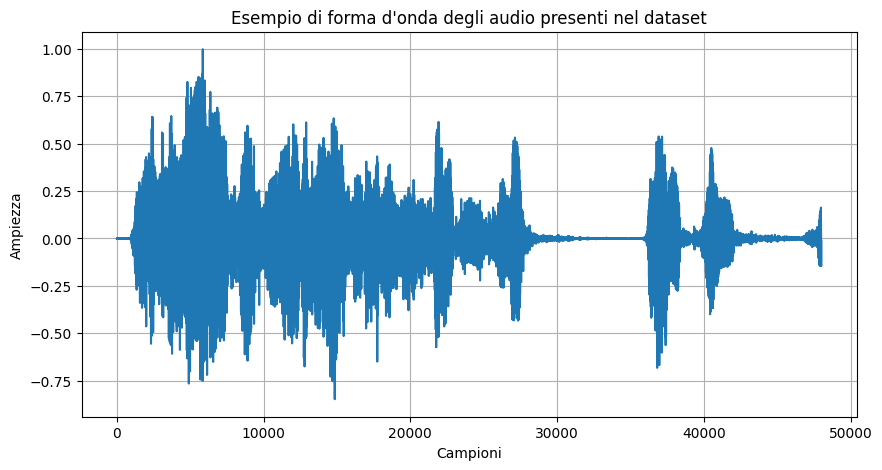

In [ ]:
sample_audio = train_audio[0]

plt.figure(figsize=(10, 5))
plt.plot(sample_audio)
plt.title("Esempio di forma d'onda degli audio presenti nel dataset")
plt.xlabel("Campioni")
plt.ylabel("Ampiezza")
plt.grid(True)
plt.show()


Per affrontare questo problema ho preso spunto dal modello presentato brevemente a lezione WaveNet, è una rete neurale convoluzionale autoregressiva sviluppata per la sintesi vocale. Tuttavia, il suo principio è stato adattato anche per la classificazione audio.

Ho costruito il residual block in modo che fosse un unità di calcolo composta da convoluzioni dilatatate, normalizzazione batch e connessioni residuali. Per quanto riguarda i diversi parametri in input:

*   x ➡ input del blocco, un tensore 1D
*   skip_outputs ➡ lista in cui vengono salvati output dei blocchi per una somma finale
*   filters ➡ numero di filtri usati per la convoluzione
*   kernel_size ➡ dimensione del kernel per la convoluzione
*   dilation_rate ➡ per indicare il tasso di dilatazione
*   regularizer ➡ per vincolo sui pesi del modello

Per quanto riguarda la strutturea del blocco, questo è formato da 2 livelli convoluzionali 1D, entrambi seguiti da livelli che fanno batch normalization per stabilizzare l'addestramento e migliorare la generalizzazione.

Successivamente è presente una connessione residuale che somma l'input originale con l'output convoluzionale per preservare il flusso dell'informazione evitando il problema del vanishing gradient.

Infine l'output viene salvato in skip_outputs in modo da creare una connessione diretta tra i livelli iniziali e quelli finali.



In [ ]:
def residual_block(x, skip_outputs, filters, kernel_size, dilation_rate, regularizer=None):

    conv = Conv1D(filters, kernel_size, dilation_rate=dilation_rate, padding="causal", activation="relu", kernel_regularizer=regularizer)(x)
    conv = BatchNormalization()(conv)
    conv = Conv1D(filters, kernel_size, dilation_rate=dilation_rate, padding="causal", kernel_regularizer=regularizer)(conv)
    conv = BatchNormalization()(conv)

    residual_output = Add()([x, conv])

    skip_outputs.append(conv)

    return residual_output

Qui definisco il modello vero e proprio. Per quanto riguarda l'input è una sequenza monodimensionale. La rete sarà composta da un numero di blocchi data dal prodotto num_blocks x num_stacks. Per quanto riguarda il regolarizzatore ho deciso di usare l2 per penalizzare i pesi grandi. Come descritto in WaveNet ho usato una dilatazione esponenziale per catturare delle relazioni a lungo termine.

Dopo i cicli for annidati vi è la somma delle skip connections salvate durante la costruzione della rete, questo permette al modello di avere accesso alle features apprese in ogni blocco.

Successivamente grazie al global pooling riassumo tutte le informazioni ottenute in un unico valore.

Infine ho uno strato completamente connesso formato da 128 neuroni, non tutti attivi per tentare di ridurre il fenomeno dell'overfitting.

Per quanto riguarda il layer di output, grazie alla softmax siamo sicuri che la somma delle probabilità delle diverse classi sia 1, questo permette che il modello restituisca una probabilità per ogni categoria.

In [ ]:
def create_wavenet_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    x = inputs
    num_blocks = 6
    num_stacks = 2
    filters = 64
    kernel_size = 3
    regularizer = l2(0.01)

    skip_outputs = []

    for _ in range(num_stacks):
        dilation_rate = 1
        for _ in range(num_blocks):
            x = residual_block(x, skip_outputs, filters, kernel_size, dilation_rate, regularizer)
            dilation_rate *= 2
            if dilation_rate > 16:
                dilation_rate = 1

    x = Add()(skip_outputs)

    x = GlobalAveragePooling1D()(x)

    x = Dense(128, activation="relu")(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    return Model(inputs, outputs)

In questa fase vi è la preparazione e la compilazione del modello, inoltre eseguo la funzione summary() sul modello in modo da averne una visione globale. Ho usato l'ottimizzatore Adam con un passo per aggiornare i pesi molto piccolo, per la loss ho utilizzato la categorical cross-entropy per misurare quanto il modello si discosti dalle labels reali durante l'addestramento, il modello tanto più si discosta, tanto più viene penalizzato. Infine come metrica ho definito l'accuratezza, che valuta la percentuale di predizioni corrette fatte dal modello.


In [ ]:
input_shape = (48000, 1)
num_classes = len(class_names)
model = create_wavenet_model(input_shape, num_classes)

In [ ]:
model.summary()

Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_19            │ (None, 48000, 1)       │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d (Conv1D)           │ (None, 48000, 64)      │            256 │ input_layer_19[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_38    │ (None, 48000, 64)      │            256 │ conv1d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_1 (Conv1D)         │ (None, 48000, 64)      │         12,352 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_39    │ (None, 48000, 64)      │            256 │ conv1d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 48000, 64)      │              0 │ input_layer_19[0][0],  │
│                           │                        │                │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_2 (Conv1D)         │ (None, 48000, 64)      │         12,352 │ add[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_40    │ (None, 48000, 64)      │            256 │ conv1d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_3 (Conv1D)         │ (None, 48000, 64)      │         12,352 │ batch_normalization_4… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_41    │ (None, 48000, 64)      │            256 │ conv1d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_1 (Add)               │ (None, 48000, 64)      │              0 │ add[0][0],             │
│                           │                        │                │ batch_normalization_4… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_4 (Conv1D)         │ (None, 48000, 64)      │         12,352 │ add_1[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_42    │ (None, 48000, 64)      │            256 │ conv1d_4[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_5 (Conv1D)         │ (None, 48000, 64)      │         12,352 │ batch_normalization_4… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_43    │ (None, 48000, 64)      │            256 │ conv1d_5[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├──────────────────────

 Total params: 299,203 (1.14 MB)

 Trainable params: 296,131 (1.13 MB)

 Non-trainable params: 3,072 (12.00 KB)

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
              loss="categorical_crossentropy", metrics=["accuracy"])

Qui addestro il modello, utilizzo l'early stopping per evitare l'overfitting e migliorare l'efficienza nell'addestramento, il valore osservato è la validation loss e, se non vi è un miglioramento per un determinato numero di epoche, l'addestramento viene interrotto ripristinando i pesi trovati per il valore migliore.

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
)

history = model.fit(
    train_audio, train_labels,
    epochs=150,
    batch_size=8,
    validation_data=(val_audio, val_labels),
    callbacks=[early_stopping]
)

Epoch 1/150
41/41 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.5683 - loss: 15.5243 - val_accuracy: 0.3061 - val_loss: 14.8477
Epoch 2/150
41/41 ━━━━━━━━━━━━━━━━━━━━ 34s 821ms/step - accuracy: 0.7253 - loss: 14.2101 - val_accuracy: 0.6122 - val_loss: 13.9008
Epoch 3/150
41/41 ━━━━━━━━━━━━━━━━━━━━ 41s 812ms/step - accuracy: 0.7376 - loss: 13.3702 - val_accuracy: 0.4694 - val_loss: 13.2365
Epoch 4/150
41/41 ━━━━━━━━━━━━━━━━━━━━ 41s 814ms/step - accuracy: 0.6684 - loss: 12.5175 - val_accuracy: 0.4082 - val_loss: 13.3643
Epoch 5/150
41/41 ━━━━━━━━━━━━━━━━━━━━ 41s 811ms/step - accuracy: 0.7531 - loss: 11.6668 - val_accuracy: 0.4082 - val_loss: 13.4325
Epoch 6/150
41/41 ━━━━━━━━━━━━━━━━━━━━ 41s 814ms/step - accuracy: 0.7784 - loss: 10.8088 - val_accuracy: 0.4082 - val_loss: 12.6925
Epoch 7/150
41/41 ━━━━━━━━━━━━━━━━━━━━ 33s 811ms/step - accuracy: 0.7838 - loss: 10.0641 - val_accuracy: 0.4286 - val_loss: 10.7241
Epoch 8/150
41/41 ━━━━━━━━━━━━━━━━━━━━ 41s 816ms/step - accuracy: 0.7225 - loss

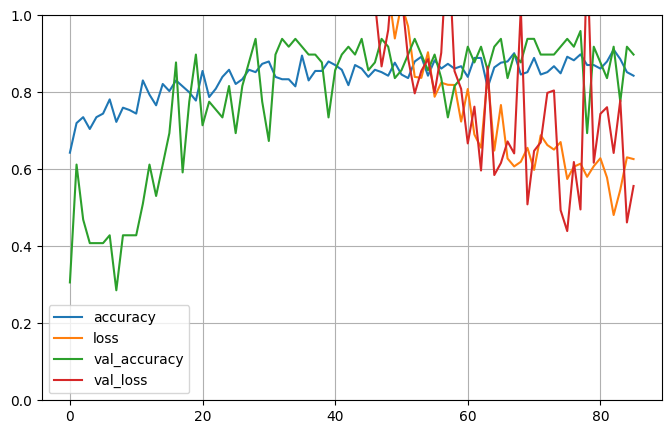

In [ ]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

Qui infine valuto come il modello si comporta su dati che non ha mai visto.

In [ ]:
test_loss, test_accuracy = model.evaluate(test_audio, test_labels, batch_size=8)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.9520 - loss: 0.4145


2/2 ━━━━━━━━━━━━━━━━━━━━ 23s 8s/step


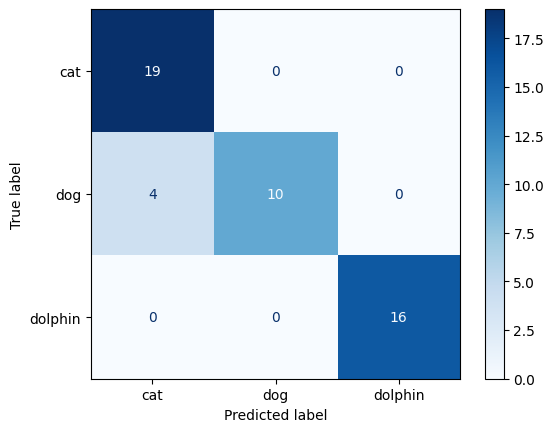

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(test_audio)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(test_labels, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues")
plt.show()

# Modello 2 - Analisi dello spettrogramma

In questo secondo modello prendo in input le forme d'onda e le trasformo in spettrogrammi prima di procedere all'addestramento del modello. Questi possono essere visti come dati che hanno una struttura a griglia con topologia 2D. Per il training di questo modello non è necessaria la GPU, ma è consigliata per una computazione più rapida.


In [ ]:
mel_spec_layer = layers.MelSpectrogram(
    fft_length=2048,
    sequence_stride=512,
    sequence_length=None,
    window="hann",
    sampling_rate=16000,
    num_mel_bins=128,
    min_freq=20.0,
    max_freq=None,
    power_to_db=True,
    top_db=80.0,
    mag_exp=2.0,
    min_power=1e-10,
    ref_power=1.0
)

Etichetta:  [0. 1. 0.]
Etichetta decodificata:  dog


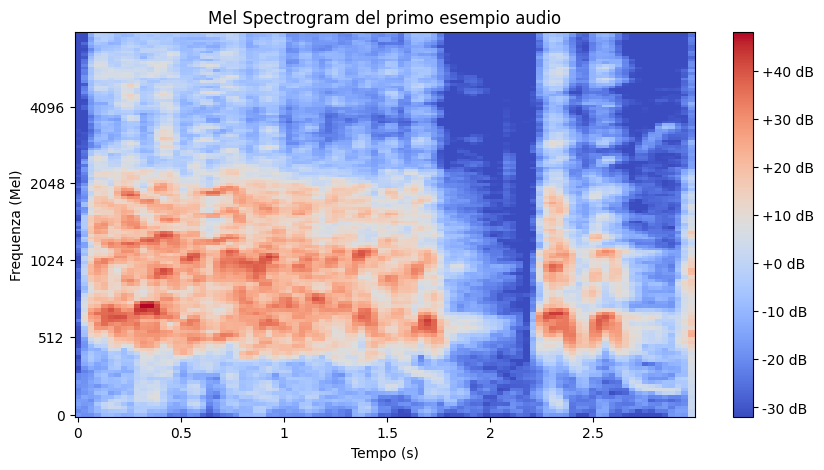

In [ ]:
i=0
sample_audio = train_audio[i]
print("Etichetta: ", train_labels[i].numpy())
label_index = tf.argmax(train_labels[i], axis=-1).numpy()
print("Etichetta decodificata: ", class_names[label_index])

sample_audio = tf.squeeze(sample_audio, axis=-1)

mel_spectrogram = mel_spec_layer(tf.expand_dims(sample_audio, axis=0))[0].numpy()

plt.figure(figsize=(10, 5))
librosa.display.specshow(
    mel_spectrogram,
    sr=16000,
    hop_length=512,
    x_axis="time",
    y_axis="mel"
)
plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram del primo esempio audio")
plt.xlabel("Tempo (s)")
plt.ylabel("Frequenza (Mel)")
plt.show()


Per affronatare questo problema ho deciso di utilizzare una CNN, in quanto gli spettrogrammi sono rappresentazioni bidimensionali simili a delle immagini e le CNN sono perfette per individuare pattern locali in questi tipi di rappresentazioni.

Per prima cosa ho usato un layer lambda per applicare la funzione mel_spec_layer ai dati audio, l'output è uno spettrogramma Mel bidimensionale.

Successivamente ho utilizzato un altro layer lambda per specificare la profondità del canale, nel caso particolare 1.

Poi applico un convoluzione bidimensionale con uno specifico numero di filtri e specificata dimensione del kernel. Per quanto riguarda il padding fa in modo di mantenere le dimensioni originali dell'input. Come regolarizzatore utilizzo l2 per evitare l'overfitting. Il tutto è seguito da batchNormalization per accelerare training e migliorare la stabilità.

Successivamente faccio la stessa cosa modificando solo il numero di filtri.

Infine riduco la dimensione dell'output prendendo la media globale delle attivazioni grazie al global pooling, utilizzo un livello completamente connesso con ReLu come funzione d'attivazione per la non linearità, applico il dropout per una migliore generalizzazione dei risultati ed per evitare overfitting. Utilizzo poi la softmax per ottenere una distribuzione di probabilità sulle classi.


In [ ]:
def create_cnn_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    x = Lambda(lambda audio: mel_spec_layer(tf.expand_dims(audio, axis=0))[0])(inputs)

    x = Lambda(lambda t: tf.expand_dims(t, axis=-1))(x)

    x = Conv2D(32, (3, 3), activation="relu", padding="same", kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Conv2D(64, (5, 5), activation="relu", padding="same", kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)

    x = GlobalAveragePooling2D()(x)

    x = Dense(128, activation="relu")(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    return Model(inputs, outputs)

In questa fase vi è la preparazione e la compilazione del modello, inoltre eseguo la funzione summary() sul modello in modo da averne una visione globale. Ho usato l'ottimizzatore Adam con un passo per aggiornare i pesi molto piccolo, per la loss ho utilizzato la categorical cross-entropy per misurare quanto il modello si discosti dalle labels reali durante l'addestramento, il modello tanto più si discosta, tanto più viene penalizzato. Infine come metrica ho definito l'accuratezza, che valuta la percentuale di predizioni corrette fatte dal modello.

In [ ]:
input_shape = (48000,)
num_classes = len(class_names)

model = create_cnn_model(input_shape, num_classes)

In [ ]:
model.summary()

Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_18 (InputLayer)          │ (None, 48000)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda_36 (Lambda)                   │ (None, 128, 94)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda_37 (Lambda)                   │ (None, 128, 94, 1)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_36 (Conv2D)                   │ (None, 128, 94, 32)         │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_36               │ (None, 128, 94, 32)         │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_37 (Conv2D)                   │ (None, 128, 94, 64)         │          51,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_37               │ (None, 128, 94, 64)         │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_18          │ (None, 64)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_36 (Dense)                     │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_18 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_37 (Dense)                     │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 60,675 (237.01 KB)

 Trainable params: 60,483 (236.26 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
              loss="categorical_crossentropy", metrics=["accuracy"])

Qui addestro il modello, utilizzo l'early stopping per evitare l'overfitting e migliorare l'efficienza nell'addestramento, il valore osservato è la validation loss e, se non vi è un miglioramento per un determinato numero di epoche, l'addestramento viene interrotto ripristinando i pesi trovati per il valore migliore.

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
)

history = model.fit(
    train_audio, train_labels,
    epochs=150,
    batch_size=16,
    validation_data=(val_audio, val_labels),
    callbacks=[early_stopping]
)

Epoch 1/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 192ms/step - accuracy: 0.4550 - loss: 1.4602 - val_accuracy: 0.4694 - val_loss: 1.5718
Epoch 2/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6159 - loss: 1.2670 - val_accuracy: 0.5510 - val_loss: 1.3966
Epoch 3/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6447 - loss: 1.2469 - val_accuracy: 0.5918 - val_loss: 1.2726
Epoch 4/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6938 - loss: 1.0988 - val_accuracy: 0.6939 - val_loss: 1.1352
Epoch 5/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6873 - loss: 1.0422 - val_accuracy: 0.5306 - val_loss: 1.1375
Epoch 6/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6943 - loss: 1.0222 - val_accuracy: 0.6939 - val_loss: 0.9846
Epoch 7/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7220 - loss: 0.9662 - val_accuracy: 0.7551 - val_loss: 0.9063
Epoch 8/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7298 - loss: 0.9243 - val_accuracy: 0

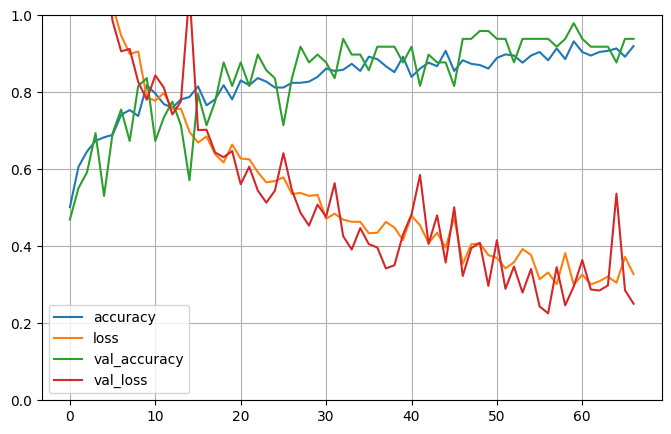

In [ ]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

Qui infine valuto come il modello si comporta su dati che non ha mai visto.

In [ ]:
test_loss, test_accuracy = model.evaluate(test_audio, test_labels, batch_size=16)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9486 - loss: 0.2828


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 757ms/step


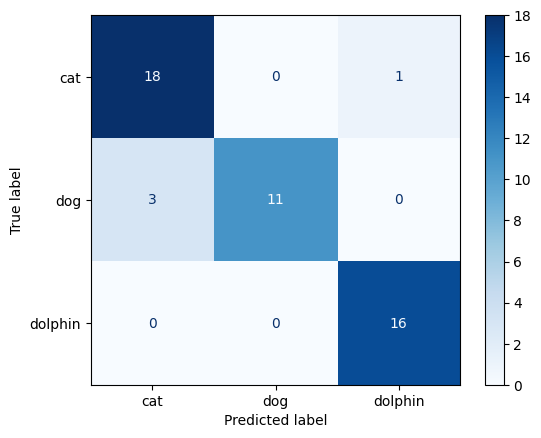

In [ ]:
y_pred = model.predict(test_audio)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(test_labels, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues")
plt.show()
